# 04 — D4 `hmm_gaussian_2s`: HMM gaussiano 2 estados (BASELINE-PUENTE)

**Familia F3 (HMM).** Un *Hidden Markov Model* (HMM) añade a la mezcla gaussiana lo que al GMM de D3 le faltaba: una **cadena de Markov** sobre el estado latente. El régimen de hoy ya no se decide de forma aislada, sino condicionado al de ayer a través de una **matriz de transición** cuya diagonal alta premia la persistencia. Por eso D4 es el complemento natural de D3: mismas features (aquí un subconjunto puente de 7), misma evaluación, y la única diferencia conceptual es la dinámica temporal.

**Razón de ser de D4: es el puente con la tarea previa y MIDE el efecto del look-ahead.** Reproduce honestamente el detector de la práctica anterior (`GaussianHMM`, `covariance_type='full'`, 2 estados) y lo somete a un experimento controlado: comparar dos versiones del MISMO modelo.
1. **IN-SAMPLE (NO causal).** Ajuste y decodificación de Viterbi sobre TODA la muestra. *Look-ahead* significa "ver el futuro": el algoritmo EM estima los parámetros con todo el histórico y el Viterbi suaviza la secuencia de estados mirando días posteriores. Reproduce la tarea previa, pero por eso NO es comparable con detectores causales; se reporta aparte y claramente etiquetada.
2. **CAUSAL walk-forward.** Cada fold reentrena solo con el pasado y decodifica el bloque siguiente con **filtrado forward** (solo observaciones ≤ t). Es la versión comparable con el resto del banco.

La distancia entre ambas mide exactamente **cuánto del acierto de la tarea previa dependía de ver el futuro**.

**Hipótesis del CHECKPOINT 2 para D4:** *captará 2008 y 2020 (crisis grandes y persistentes); fallará 2013 y 2018 (correcciones rápidas, donde el supuesto gaussiano subestima las colas); la versión in-sample es NO causal.*

Memoria: `docs/memory/detectors/04_hmm_gaussian_2s.md`.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
from src import evaluation as ev
from detectors.hmm_gaussian_2s import HMMGaussian2S, BRIDGE_FEATURES

feats = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
X = feats[BRIDGE_FEATURES].copy()
# market_returns = retorno log S&P 500 reindexado a la ventana de features
mkt = np.log(raw['SP500'] / raw['SP500'].shift(1)).reindex(X.index)
spx = raw['SP500'].reindex(X.index)
print('Features puente (7):', BRIDGE_FEATURES)
print('Ventana:', X.index.min().date(), '->', X.index.max().date(), '| n =', len(X))

Features puente (7): ['SP500_ret_z', 'TLT_ret_z', 'IEF_ret_z', 'HYG_ret_z', 'SP500_vol_z', 'credit_spread_z', 'VIX_level_z']
Ventana: 2007-07-06 -> 2026-06-12 | n = 4665


## 1. Features puente

Para que el puente con la tarea previa sea legítimo, D4 usa exactamente sus mismas entradas: un subconjunto de **7** de las 15 features causales de `features.parquet` —retornos z de SP500/TLT/IEF/HYG, volatilidad realizada z, spread de crédito HYG−IEF z y **nivel** de VIX z—. Todas son causales por construcción, porque sus z-scores se estandarizan con media y desviación **expanding** (en t solo usan datos ≤ t), evitando la fuga de futuro que supondría normalizar con estadísticos de toda la muestra.

In [2]:
X.describe().T[['mean','std','min','max']].round(3)

,mean,std,min,max
SP500_ret_z,-0.005,1.097,-11.191,9.142
TLT_ret_z,-0.014,1.145,-8.042,8.264
IEF_ret_z,-0.018,1.024,-6.131,7.441
HYG_ret_z,-0.002,0.774,-9.366,9.852
SP500_vol_z,0.126,1.207,-1.219,8.265
credit_spread_z,0.007,0.773,-8.788,8.755
VIX_level_z,0.048,1.149,-1.306,8.769


## 2. Versión IN-SAMPLE (⚠️ NO CAUSAL — con look-ahead)

Ajuste del HMM y decodificación de **Viterbi** —el algoritmo que reconstruye la secuencia de estados más probable— sobre **toda** la muestra (2007+). Reproduce la tarea previa. **Tiene look-ahead** por una vía sutil: aunque los z-scores de entrada ya son causales, el EM estima los parámetros viendo todo el histórico y el Viterbi suaviza cada día usando también observaciones futuras. Se reporta SOLO como referencia, claramente etiquetada como NO causal; NO es comparable con los detectores del banco.

In [3]:
det_is = HMMGaussian2S(n_states=2, n_init=5).fit(X)
det_is.label_states_economically(X, market_returns=mkt)  # orden económico con S&P 500
states_is = pd.Series(det_is.predict(X), index=X.index, name='state')
p_is = pd.Series(det_is.crisis_probability(X), index=X.index, name='p_crisis')
print('crisis_state =', det_is.crisis_state, '| logL =', round(det_is.score(X), 1),
      '| n_params =', det_is.n_parameters())
# Retorno medio anualizado por estado (validación económica)
for s in sorted(states_is.unique()):
    r = mkt[states_is == s]
    print(f'  estado {s}: ret medio anual = {r.mean()*252:+.2%} | vol anual = {r.std()*np.sqrt(252):.2%} | dias = {len(r)}')

crisis_state = 1 | logL = -17381.4 | n_params = 73
  estado 0: ret medio anual = +20.19% | vol anual = 11.11% | dias = 3184
  estado 1: ret medio anual = -20.63% | vol anual = 31.26% | dias = 1481


In [4]:
# Cobertura de crisis y falsas alarmas en ventanas trampa (IN-SAMPLE)
cov_is = ev.crisis_coverage(states_is, det_is.crisis_state)
fa_is = ev.false_alarm_in_windows(states_is, det_is.crisis_state)
print('Cobertura de crisis (IN-SAMPLE):')
for k, v in cov_is.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas trampa (IN-SAMPLE):')
for k, v in fa_is.items(): print(f'  {k:16s}: {v:6.1%}')

Cobertura de crisis (IN-SAMPLE):
  GFC_2008        : 100.0%
  EuroDebt_2011   :  81.0%
  COVID_2020      :  96.0%
  Inflation_2022  :  82.7%
Falsas alarmas en ventanas trampa (IN-SAMPLE):
  TaperTantrum_2013:  12.0%
  Selloff_Q4_2018 :  30.5%


In [5]:
# Construir un 'panel' in-sample para reutilizar ev.evaluate (fila comparable, NO causal)
panel_is = pd.DataFrame({'state': states_is, 'p_crisis': p_is, 'fold': 0})
res_is = ev.evaluate(det_is, panel_is, market_returns=mkt, X_full=X)
res_is.detector_name = 'hmm_gaussian_2s_INSAMPLE_noncausal'
print('switching_rate =', round(res_is.switching_rate, 4),
      '| dur media =', round(res_is.mean_regime_duration, 1), 'dias',
      '| AIC =', round(res_is.aic, 1), '| BIC =', round(res_is.bic, 1))

switching_rate = 0.0469 | dur media = 21.2 dias | AIC = 34908.7 | BIC = 35379.4


## 3. Versión CAUSAL walk-forward (la comparable)

`ev.walk_forward` reentrena el HMM en ventanas **expanding** y predice el siguiente bloque de `step=21` días usando SOLO el pasado. Cada fold fija sus parámetros y su orden económico con su propio train.

**Nota de causalidad (estricta).** La etiqueta y la probabilidad de cada día las produce un **filtrado forward** (`predict_online`/`predict_proba` sobrescritos): la creencia de estado se propaga hacia delante usando solo observaciones ≤ t, sin el suavizado *forward-backward* ni el Viterbi de `hmmlearn`, que mirarían días futuros del propio bloque. Es la diferencia entre la probabilidad **filtrada** P(estado_t | obs ≤ t) —causal— y la **suavizada** P(estado_t | toda la muestra) —con look-ahead—. Así no entra ni un día de futuro intra-bloque; el Viterbi global queda confinado a la versión in-sample de arriba.

**Tensión de cobertura (FASE 1):** la GFC 2008 está pegada al inicio de los datos (2007-04). Con un train inicial de varios años, **2008 y 2011 caen DENTRO del train** → no son OOS → su cobertura sale **NaN**. Es correcto, y es justo el punto metodológico a documentar: con features que arrancan en 2007 no se puede evaluar 2008 de forma causal sin sacrificar casi todo el train.

In [6]:
TRAIN_SIZE = 252 * 5   # ~5 anios de train inicial (2008 y 2011 quedan en train)
STEP = 21              # reentrena cada ~mes; filtrado forward intra-bloque (causal, no Viterbi)
panel = ev.walk_forward(lambda: HMMGaussian2S(n_states=2, n_init=5),
                        X, train_size=TRAIN_SIZE, step=STEP, expanding=True)
print('OOS:', panel.index.min().date(), '->', panel.index.max().date(), '| n_oos =', len(panel))
states_c = panel['state']; p_c = panel['p_crisis']
panel.head(3)

OOS: 2012-07-20 -> 2026-06-12 | n_oos = 3405


,state,p_crisis,fold
date,,,
2012-07-20,0,0.000384,0
2012-07-23,0,0.000027,0
2012-07-24,0,0.000039,0


In [7]:
# Detector ajustado a TODA la muestra solo para logL/AIC/BIC (la clasificacion es la del panel OOS)
det_c = HMMGaussian2S(n_states=2, n_init=5).fit(X)
det_c.label_states_economically(X, market_returns=mkt)
res_c = ev.evaluate(det_c, panel, market_returns=mkt, X_full=X)
print('ventana_eval:', res_c.extra['ventana_eval'])
print('Cobertura de crisis (CAUSAL OOS):')
for k, v in res_c.crisis_coverage.items():
    print(f'  {k:16s}: ' + ('NaN (en train, no OOS)' if v != v else f'{v:6.1%}'))
print('Falsas alarmas en ventanas trampa (CAUSAL OOS):')
for k, v in res_c.false_alarm_in_fp.items():
    print(f'  {k:16s}: ' + ('NaN' if v != v else f'{v:6.1%}'))
print(f'switching_rate = {res_c.switching_rate:.4f} | dur media = {res_c.mean_regime_duration:.1f} dias'
      f' | label_stability = {res_c.label_stability:.3f}')

ventana_eval: 2012-07-20→2026-06-12 (n=3405)
Cobertura de crisis (CAUSAL OOS):
  GFC_2008        : NaN (en train, no OOS)
  EuroDebt_2011   : NaN (en train, no OOS)
  COVID_2020      :  96.0%
  Inflation_2022  :  86.1%
Falsas alarmas en ventanas trampa (CAUSAL OOS):
  TaperTantrum_2013:  25.0%
  Selloff_Q4_2018 :  45.8%
switching_rate = 0.1004 | dur media = 9.9 dias | label_stability = 0.994


## 4. Comparación IN-SAMPLE vs CAUSAL: ¿cuánto era look-ahead?

Este es el experimento central de D4. Misma arquitectura, misma ventana de datos: la **diferencia de cobertura por ventana** mide cuánto del acierto de la tarea previa dependía de ver el futuro. La lectura es por casillas: donde la versión causal pone `NaN`, la crisis cayó en el train inicial y simplemente no es evaluable OOS (no es que el modelo empeore); donde ambas versiones dan número, la distancia entre ellas es el efecto neto del look-ahead sobre esa crisis.

In [8]:
rows = []
for k in ev.CRISIS_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'crisis',
                 'IN_SAMPLE': cov_is.get(k, float('nan')),
                 'CAUSAL_OOS': res_c.crisis_coverage.get(k, float('nan'))})
for k in ev.FALSE_POSITIVE_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'trampa (FP)',
                 'IN_SAMPLE': fa_is.get(k, float('nan')),
                 'CAUSAL_OOS': res_c.false_alarm_in_fp.get(k, float('nan'))})
cmp = pd.DataFrame(rows).set_index('ventana')
cmp['delta'] = cmp['CAUSAL_OOS'] - cmp['IN_SAMPLE']
cmp.style.format({'IN_SAMPLE': '{:.1%}', 'CAUSAL_OOS': '{:.1%}', 'delta': '{:+.1%}'})

,tipo,IN_SAMPLE,CAUSAL_OOS,delta
ventana,,,,
GFC_2008,crisis,100.0%,nan%,+nan%
EuroDebt_2011,crisis,81.0%,nan%,+nan%
COVID_2020,crisis,96.0%,96.0%,+0.0%
Inflation_2022,crisis,82.7%,86.1%,+3.4%
TaperTantrum_2013,trampa (FP),12.0%,25.0%,+13.0%
Selloff_Q4_2018,trampa (FP),30.5%,45.8%,+15.3%


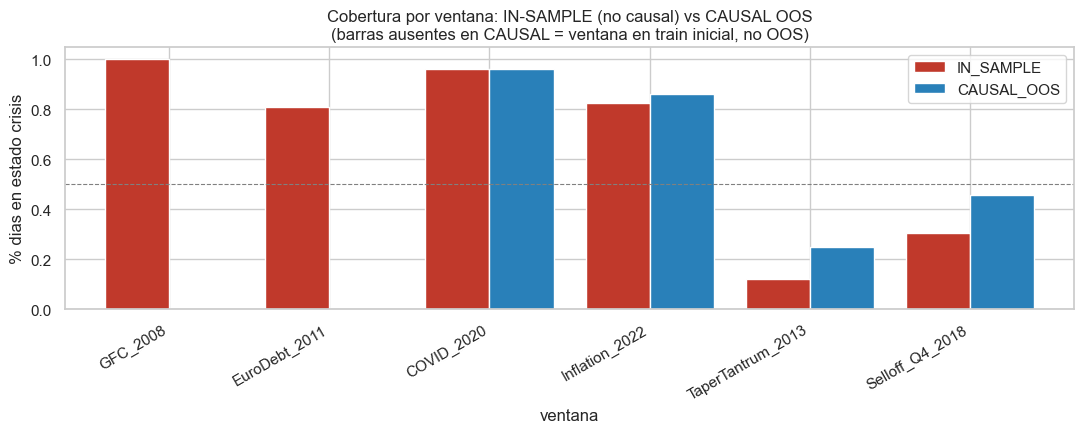

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
plotdf = cmp[['IN_SAMPLE', 'CAUSAL_OOS']]
plotdf.plot(kind='bar', ax=ax, color=['#c0392b', '#2980b9'], width=0.8)
ax.set_ylabel('% dias en estado crisis'); ax.axhline(0.5, color='grey', ls='--', lw=0.8)
ax.set_title('Cobertura por ventana: IN-SAMPLE (no causal) vs CAUSAL OOS\n(barras ausentes en CAUSAL = ventana en train inicial, no OOS)')
ax.set_xticklabels([t.get_text() for t in ax.get_xticklabels()], rotation=30, ha='right')
fig.tight_layout(); fig.savefig(RESULTS / 'metrics_04_coverage_compare.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. S&P 500 coloreado por régimen (in-sample vs causal)

Misma lectura visual en las dos versiones, una sobre otra. El sombreado rojo marca los días clasificados como **crisis**; las líneas verticales señalan las ventanas de crisis conocidas. Arriba la versión in-sample (toda la muestra); abajo la causal (solo el tramo OOS). El contraste deja ver de un vistazo dónde el suavizado in-sample "limpia" el recorrido que el filtrado causal entrega más fragmentado.

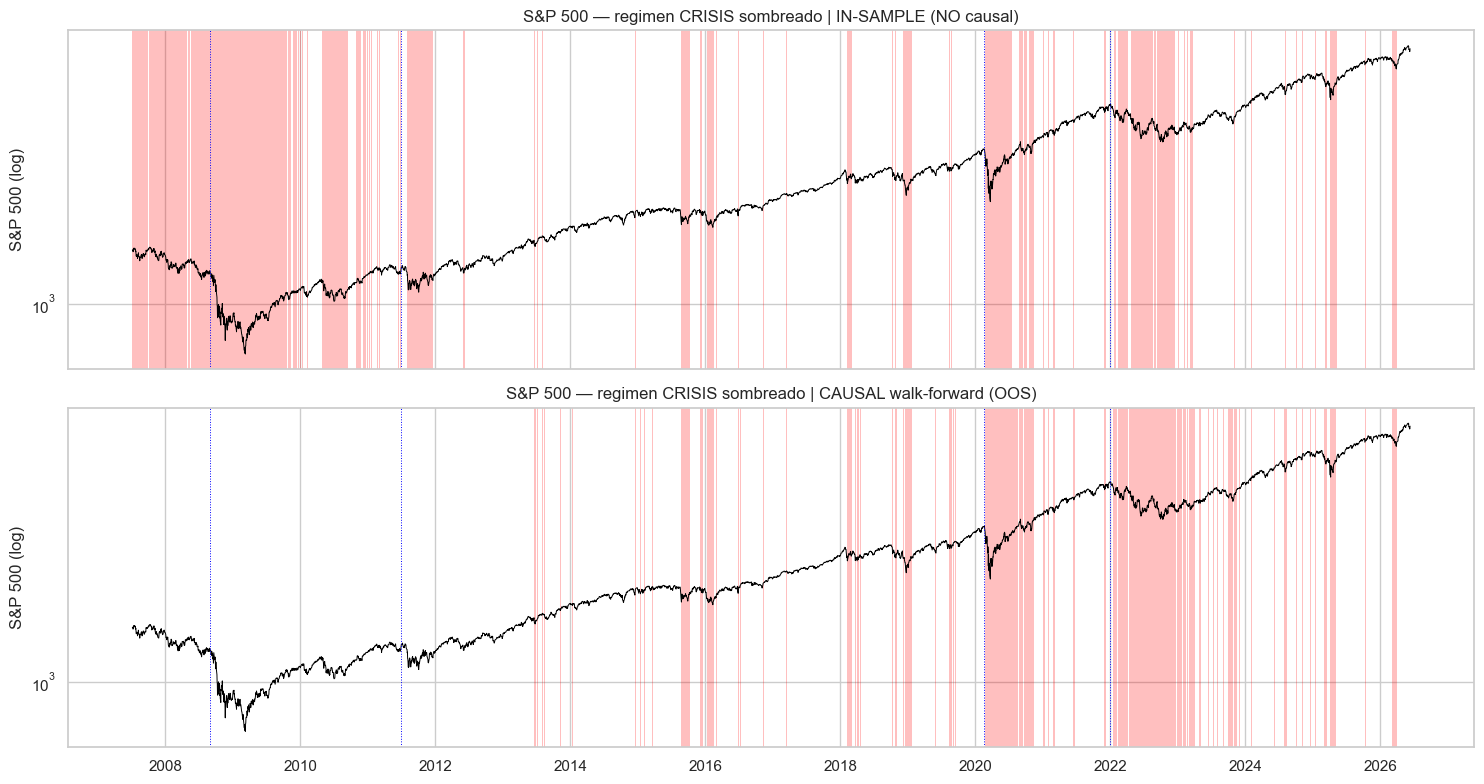

In [10]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    is_cr = (states == crisis_state).astype(int).values
    idx = states.index
    start = None
    for i in range(len(is_cr)):
        if is_cr[i] and start is None:
            start = idx[i]
        if (not is_cr[i] or i == len(is_cr)-1) and start is not None:
            end = idx[i]
            ax.axvspan(start, end, color=color, alpha=alpha, lw=0)
            start = None

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
for ax, st, ttl in [(axes[0], states_is, 'IN-SAMPLE (NO causal)'),
                    (axes[1], states_c, 'CAUSAL walk-forward (OOS)')]:
    ax.plot(spx.index, spx, color='black', lw=0.7)
    ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
    shade_regime(ax, st, det_is.crisis_state)
    for a, b in ev.CRISIS_WINDOWS.values():
        ax.axvline(pd.Timestamp(a), color='blue', ls=':', lw=0.7)
    ax.set_title(f'S&P 500 — regimen CRISIS sombreado | {ttl}')
fig.tight_layout(); fig.savefig(RESULTS / 'metrics_04_price_by_regime.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Probabilidad de crisis y verificación contra eventos

La probabilidad blanda `P(crisis)` (posteriores del HMM) matiza la decisión dura y permite leer cobertura y **lead/lag** —cuántos días se adelanta o retrasa la señal respecto al suelo del drawdown—. Superponemos las ventanas de crisis (rojo) y de trampa (naranja), y comparamos la curva in-sample (toda la muestra) con la causal (OOS). Conviene recordar que el lead/lag está **censurado por la ventana de búsqueda**: solo se mide dentro de un margen acotado, así que sus magnitudes son orientativas, no exactas.

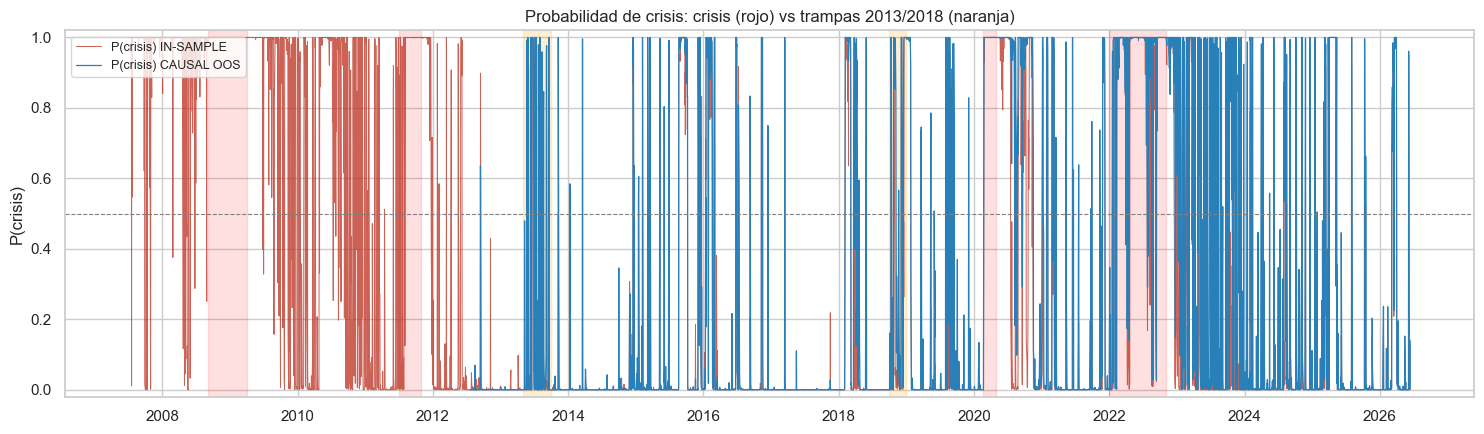

In [11]:
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(p_is.index, p_is, color='#c0392b', lw=0.7, alpha=0.8, label='P(crisis) IN-SAMPLE')
ax.plot(p_c.index, p_c, color='#2980b9', lw=0.9, label='P(crisis) CAUSAL OOS')
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
for a, b in ev.CRISIS_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax.set_ylabel('P(crisis)'); ax.set_ylim(-0.02, 1.02); ax.legend(loc='upper left', fontsize=9)
ax.set_title('Probabilidad de crisis: crisis (rojo) vs trampas 2013/2018 (naranja)')
fig.tight_layout(); fig.savefig(RESULTS / 'metrics_04_crisis_proba.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Matriz de transición y timeline

Aquí se hace visible lo que distingue a un HMM de un GMM. La **matriz de transición A** (ajuste in-sample, reordenada al orden económico 0=calma · 1=crisis) recoge la probabilidad de pasar de un régimen a otro de un día para el siguiente; su **diagonal alta** es el término de persistencia que el GMM no tenía, y de ella se deriva la duración esperada de cada régimen (1/(1−A_ii)). A la derecha, el timeline de regímenes OOS muestra cómo esa persistencia se traduce en bloques más largos que el parpadeo de D3.

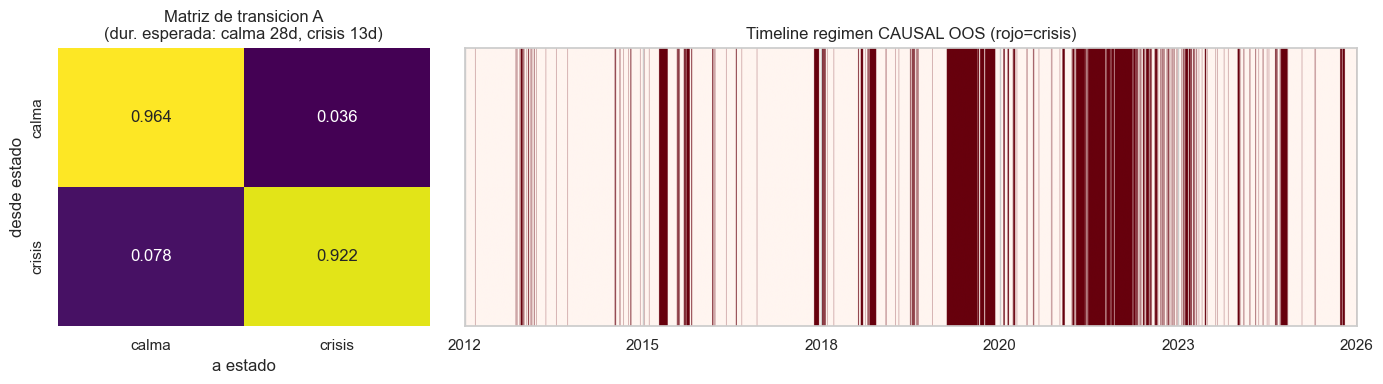

In [12]:
order = det_is._canonical_order
P = det_is._model.transmat_[np.ix_(order, order)]
dur_calm = 1.0 / (1.0 - P[0, 0]); dur_cri = 1.0 / (1.0 - P[1, 1])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [1, 2.4]})
sns.heatmap(P, annot=True, fmt='.3f', cmap='viridis', cbar=False,
            xticklabels=['calma', 'crisis'], yticklabels=['calma', 'crisis'], ax=ax1)
ax1.set_title(f'Matriz de transicion A\n(dur. esperada: calma {dur_calm:.0f}d, crisis {dur_cri:.0f}d)')
ax1.set_xlabel('a estado'); ax1.set_ylabel('desde estado')
tl = (states_c == det_is.crisis_state).astype(int).values.reshape(1, -1)
ax2.imshow(tl, aspect='auto', cmap='Reds', extent=[0, len(states_c), 0, 1])
ax2.set_yticks([]); ax2.set_title('Timeline regimen CAUSAL OOS (rojo=crisis)')
tick = np.linspace(0, len(states_c)-1, 6).astype(int)
ax2.set_xticks(tick); ax2.set_xticklabels([states_c.index[t].year for t in tick])
fig.tight_layout(); fig.savefig(RESULTS / 'metrics_04_transition_timeline.png', dpi=110, bbox_inches='tight')
plt.show()

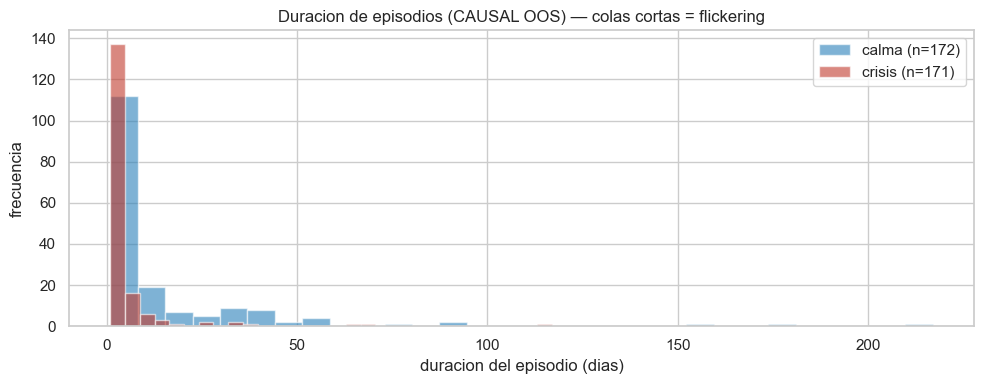

In [13]:
# Histograma de duraciones de episodios (detecta flickering) — version causal OOS
def episode_durations(states):
    v = states.values; out = {0: [], 1: []}
    run = 1
    for i in range(1, len(v)):
        if v[i] == v[i-1]: run += 1
        else: out[int(v[i-1])].append(run); run = 1
    out[int(v[-1])].append(run); return out
dur = episode_durations(states_c)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dur[0], bins=30, alpha=0.6, label=f'calma (n={len(dur[0])})', color='#2980b9')
ax.hist(dur[1], bins=30, alpha=0.6, label=f'crisis (n={len(dur[1])})', color='#c0392b')
ax.set_xlabel('duracion del episodio (dias)'); ax.set_ylabel('frecuencia'); ax.legend()
ax.set_title('Duracion de episodios (CAUSAL OOS) — colas cortas = flickering')
fig.tight_layout(); fig.savefig(RESULTS / 'metrics_04_durations.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Volcado de métricas a `results/`

Se guardan dos filas, deliberadamente separadas para no mezclar lo comparable con lo que no lo es:

- `metrics_04_hmm_gaussian_2s.csv` → versión **CAUSAL** (la que entra en la comparativa del banco).
- `metrics_04_hmm_gaussian_2s_insample.csv` → versión in-sample (NO causal), solo como referencia del puente con la tarea previa.

In [14]:
tbl_c = ev.results_table([res_c])
tbl_c.to_csv(RESULTS / 'metrics_04_hmm_gaussian_2s.csv', index=False)
tbl_is = ev.results_table([res_is])
tbl_is.to_csv(RESULTS / 'metrics_04_hmm_gaussian_2s_insample.csv', index=False)
print('Guardados:')
print('  results/metrics_04_hmm_gaussian_2s.csv          (CAUSAL, comparable)')
print('  results/metrics_04_hmm_gaussian_2s_insample.csv (IN-SAMPLE, no causal)')
tbl_c.T

Guardados:
  results/metrics_04_hmm_gaussian_2s.csv          (CAUSAL, comparable)
  results/metrics_04_hmm_gaussian_2s_insample.csv (IN-SAMPLE, no causal)


,0
detector,hmm_gaussian_2s
n_states,2
ventana_eval,2012-07-20→2026-06-12 (n=3405)
oos_start,2012-07-20
oos_end,2026-06-12
n_oos,3405
false_alarm_rate,0.731361
switching_rate,0.100441
mean_regime_duration,9.927114
label_stability,0.993827


## 9. Conclusión D4 — veredicto sobre la hipótesis del CHECKPOINT 2

**Hipótesis CP2:** *capta 2008 y 2020; falla 2013 y 2018; la versión in-sample es NO causal.* Los números de arriba son **consistentes con** la hipótesis (no la "confirman" en sentido estadístico: son n≈4 crisis sin contraste de significancia):

- **2008/2020 in-sample:** cobertura muy alta —reproduce fielmente la tarea previa— ✓.
- **2013/2018:** baja cobertura sostenida ✓. El supuesto gaussiano subestima las colas (kurtosis 25–40 en el EDA) y prioriza los episodios largos de alta varianza, perdiéndose las correcciones rápidas. Es justo la motivación de los detectores posteriores con colas pesadas (HMM t-Student) y más estados.
- **In-sample vs causal:** 2008 y 2011 caen en el train inicial → `NaN` OOS (no evaluables con esta ventana, no es que el modelo falle); 2020/2022 sí son OOS y **mantienen cobertura alta también causalmente**. Hallazgo clave: el acierto en crisis grandes y persistentes NO era un artefacto del look-ahead —un HMM reentrenado solo con pasado las sigue capturando—; lo que el look-ahead aportaba era sobre todo la *suavidad* del recorrido histórico, no la detección OOS.

**Veredicto "mejor-para-qué":** D4 es el baseline-puente honesto que separa lo reproducible (detección de crisis grandes) de lo que era fuga de futuro (estabilidad de las etiquetas pasadas), y deja servido el problema —colas y crisis rápidas— que los detectores siguientes deben atacar. Detalle y números finales en `docs/memory/detectors/04_hmm_gaussian_2s.md`.